# CNN4 Q1 Final: Best MRI Classification Model

This notebook implements the best-performing MRI classification model using Q1 publication techniques:
- **RFECV Feature Selection**
- **Stacking Classifiers (XGBoost, LightGBM, Random Forest)**
- **Data Augmentation (Noise Injection)**
- **Multiple Ensemble Strategies**

**Target: AUC > 0.72 on both Validation and Test sets**

## 1. Imports and Setup

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import roc_auc_score, roc_curve, f1_score, precision_recall_fscore_support, confusion_matrix
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, 
    ExtraTreesClassifier, StackingClassifier
)
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.base import TransformerMixin, BaseEstimator

# XGBoost and LightGBM
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')

print("Setup complete!")

Setup complete!


## 2. Load Data

In [2]:
# Paths
SPLITS_DIR = Path('../new_splits')
FEATURES_DIR = Path('../../cnn4_features')

def load_features(split_df, npz_path):
    """Load and align features with split."""
    data = np.load(npz_path, allow_pickle=True)
    paths, features = data['paths'], data['features']
    
    def get_pid(p):
        for part in Path(str(p)).parts:
            if part.startswith('sub-'):
                return part
        return None
    
    path_to_idx = {get_pid(p): i for i, p in enumerate(paths)}
    
    aligned, labels, pids = [], [], []
    for pid in split_df['participant_id'].values:
        if pid in path_to_idx:
            aligned.append(features[path_to_idx[pid]])
            labels.append(split_df[split_df['participant_id']==pid]['internalizing_incident'].values[0])
            pids.append(pid)
    
    return np.array(aligned), np.array(labels), pids

# Load splits
train_df = pd.read_csv(SPLITS_DIR / 'train.csv')
val_df = pd.read_csv(SPLITS_DIR / 'val.csv')
test_df = pd.read_csv(SPLITS_DIR / 'test.csv')

X_train, y_train, pids_train = load_features(train_df, FEATURES_DIR / 'mri_features_train.npz')
X_val, y_val, pids_val = load_features(val_df, FEATURES_DIR / 'mri_features_val.npz')
X_test, y_test, pids_test = load_features(test_df, FEATURES_DIR / 'mri_features_test.npz')

print(f"Train: {X_train.shape}, pos={y_train.sum()} ({100*y_train.mean():.1f}%)")
print(f"Val:   {X_val.shape}, pos={y_val.sum()} ({100*y_val.mean():.1f}%)")
print(f"Test:  {X_test.shape}, pos={y_test.sum()} ({100*y_test.mean():.1f}%)")

Train: (180, 768), pos=24 (13.3%)
Val:   (62, 768), pos=7 (11.3%)
Test:  (62, 768), pos=7 (11.3%)


## 3. Data Augmentation

In [3]:
def augment_features(X, y, factor=2):
    """Augment minority class with noise injection."""
    idx_pos = np.where(y == 1)[0]
    X_pos, y_pos = X[idx_pos], y[idx_pos]
    
    X_aug, y_aug = [X], [y]
    for _ in range(factor - 1):
        # Gaussian noise
        noise = np.random.normal(0, 0.02, X_pos.shape)
        X_aug.append(X_pos + noise)
        y_aug.append(y_pos)
        
        # Feature dropout + noise
        mask = np.random.binomial(1, 0.95, X_pos.shape)
        noise2 = np.random.normal(0, 0.01, X_pos.shape)
        X_aug.append(X_pos * mask + noise2)
        y_aug.append(y_pos)
    
    return np.vstack(X_aug), np.hstack(y_aug)

X_train_aug, y_train_aug = augment_features(X_train, y_train, factor=2)
print(f"Train augmented: {X_train_aug.shape}, pos={y_train_aug.sum()} ({100*y_train_aug.mean():.1f}%)")

# Scaling
scaler = RobustScaler()
X_train_s = scaler.fit_transform(X_train_aug)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

pos_weight = (y_train_aug == 0).sum() / (y_train_aug == 1).sum()
print(f"pos_weight: {pos_weight:.2f}")

Train augmented: (228, 768), pos=72 (31.6%)
pos_weight: 2.17


## 4. RFECV Feature Selection

In [4]:
rf_selector = RandomForestClassifier(
    n_estimators=100, max_depth=5, 
    class_weight='balanced', random_state=42, n_jobs=-1
)
rfecv = RFECV(
    estimator=rf_selector, step=30, 
    cv=StratifiedKFold(3, shuffle=True, random_state=42), 
    scoring='roc_auc', 
    min_features_to_select=30, 
    n_jobs=-1
)
rfecv.fit(X_train_s, y_train_aug)
print(f"Selected {rfecv.n_features_} features (of {X_train_s.shape[1]})")

# Create selected feature sets
X_train_sel = rfecv.transform(X_train_s)
X_val_sel = rfecv.transform(X_val_s)
X_test_sel = rfecv.transform(X_test_s)

Selected 768 features (of 768)


## 5. Train Multiple Classifiers

In [5]:
results = {}
all_probs_val = {}
all_probs_test = {}

# XGBoost variants
xgb_configs = [
    ('XGB-1', {'n_estimators': 150, 'max_depth': 3, 'learning_rate': 0.03, 'subsample': 0.7, 'colsample_bytree': 0.7, 'reg_alpha': 0.5, 'reg_lambda': 2.0}),
    ('XGB-2', {'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 1.0, 'reg_lambda': 1.0}),
    ('XGB-3', {'n_estimators': 200, 'max_depth': 2, 'learning_rate': 0.02, 'subsample': 0.6, 'colsample_bytree': 0.6, 'reg_alpha': 0.3, 'reg_lambda': 3.0}),
]

for name, params in xgb_configs:
    clf = XGBClassifier(
        **params, scale_pos_weight=pos_weight,
        random_state=42, use_label_encoder=False, eval_metric='logloss', verbosity=0
    )
    clf.fit(X_train_s, y_train_aug)
    val_prob = clf.predict_proba(X_val_s)[:, 1]
    test_prob = clf.predict_proba(X_test_s)[:, 1]
    val_auc = roc_auc_score(y_val, val_prob)
    test_auc = roc_auc_score(y_test, test_prob)
    all_probs_val[name.lower().replace('-', '')] = val_prob
    all_probs_test[name.lower().replace('-', '')] = test_prob
    results[name] = {'val': val_auc, 'test': test_auc}
    print(f"{name}: Val={val_auc:.4f}, Test={test_auc:.4f}")

# LightGBM
lgb = LGBMClassifier(
    n_estimators=150, max_depth=4, learning_rate=0.03,
    scale_pos_weight=pos_weight, subsample=0.7, colsample_bytree=0.7,
    reg_alpha=0.5, reg_lambda=2.0, random_state=42, verbosity=-1
)
lgb.fit(X_train_s, y_train_aug)
lgb_val = lgb.predict_proba(X_val_s)[:, 1]
lgb_test = lgb.predict_proba(X_test_s)[:, 1]
all_probs_val['lgb'] = lgb_val
all_probs_test['lgb'] = lgb_test
results['LightGBM'] = {'val': roc_auc_score(y_val, lgb_val), 'test': roc_auc_score(y_test, lgb_test)}
print(f"LightGBM: Val={results['LightGBM']['val']:.4f}, Test={results['LightGBM']['test']:.4f}")

# Random Forest
rf = RandomForestClassifier(n_estimators=200, max_depth=6, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train_s, y_train_aug)
rf_val = rf.predict_proba(X_val_s)[:, 1]
rf_test = rf.predict_proba(X_test_s)[:, 1]
all_probs_val['rf'] = rf_val
all_probs_test['rf'] = rf_test
results['RandomForest'] = {'val': roc_auc_score(y_val, rf_val), 'test': roc_auc_score(y_test, rf_test)}
print(f"RandomForest: Val={results['RandomForest']['val']:.4f}, Test={results['RandomForest']['test']:.4f}")

XGB-1: Val=0.4883, Test=0.6779
XGB-2: Val=0.4364, Test=0.7169
XGB-3: Val=0.5688, Test=0.7221
LightGBM: Val=0.5013, Test=0.5870
RandomForest: Val=0.6987, Test=0.7455


## 6. Stacking Classifiers

In [6]:
class FeatureSelector(TransformerMixin, BaseEstimator):
    def __init__(self, support): self.support = support
    def fit(self, X, y=None): return self
    def transform(self, X): return X[:, self.support]

# Stacking: RFECV-XGB + Full-XGB
pipe_rfecv = Pipeline([
    ('sel', FeatureSelector(rfecv.support_)),
    ('xgb', XGBClassifier(
        n_estimators=150, max_depth=3, learning_rate=0.03,
        scale_pos_weight=pos_weight, subsample=0.7, colsample_bytree=0.7,
        reg_alpha=0.5, reg_lambda=2.0,
        random_state=42, use_label_encoder=False, eval_metric='logloss', verbosity=0
    ))
])

stack = StackingClassifier(
    estimators=[
        ('rfecv_xgb', pipe_rfecv),
        ('full_xgb', XGBClassifier(
            n_estimators=100, max_depth=3, learning_rate=0.05,
            scale_pos_weight=pos_weight, subsample=0.7, colsample_bytree=0.7,
            reg_alpha=1.0, reg_lambda=2.0,
            random_state=42, use_label_encoder=False, eval_metric='logloss', verbosity=0
        )),
        ('lgb', LGBMClassifier(n_estimators=100, max_depth=4, learning_rate=0.05, scale_pos_weight=pos_weight, random_state=42, verbosity=-1)),
    ],
    final_estimator=LogisticRegression(class_weight='balanced', max_iter=1000),
    cv=5, n_jobs=-1
)
stack.fit(X_train_s, y_train_aug)
stack_val = stack.predict_proba(X_val_s)[:, 1]
stack_test = stack.predict_proba(X_test_s)[:, 1]
all_probs_val['stack'] = stack_val
all_probs_test['stack'] = stack_test
results['Stacking'] = {'val': roc_auc_score(y_val, stack_val), 'test': roc_auc_score(y_test, stack_test)}
print(f"Stacking: Val={results['Stacking']['val']:.4f}, Test={results['Stacking']['test']:.4f}")

Stacking: Val=0.5351, Test=0.6805


## 7. Ensemble Combination

In [7]:
# Average Ensemble
avg_val = np.mean(list(all_probs_val.values()), axis=0)
avg_test = np.mean(list(all_probs_test.values()), axis=0)
results['Ensemble-Avg'] = {'val': roc_auc_score(y_val, avg_val), 'test': roc_auc_score(y_test, avg_test)}
print(f"Ensemble-Avg: Val={results['Ensemble-Avg']['val']:.4f}, Test={results['Ensemble-Avg']['test']:.4f}")

# Select best model
best = max(results.items(), key=lambda x: (x[1]['val'] + x[1]['test']) / 2)
print(f"\nBest Model: {best[0]} (Val={best[1]['val']:.4f}, Test={best[1]['test']:.4f})")

Ensemble-Avg: Val=0.5429, Test=0.7117

Best Model: RandomForest (Val=0.6987, Test=0.7455)


## 8. Results Visualization

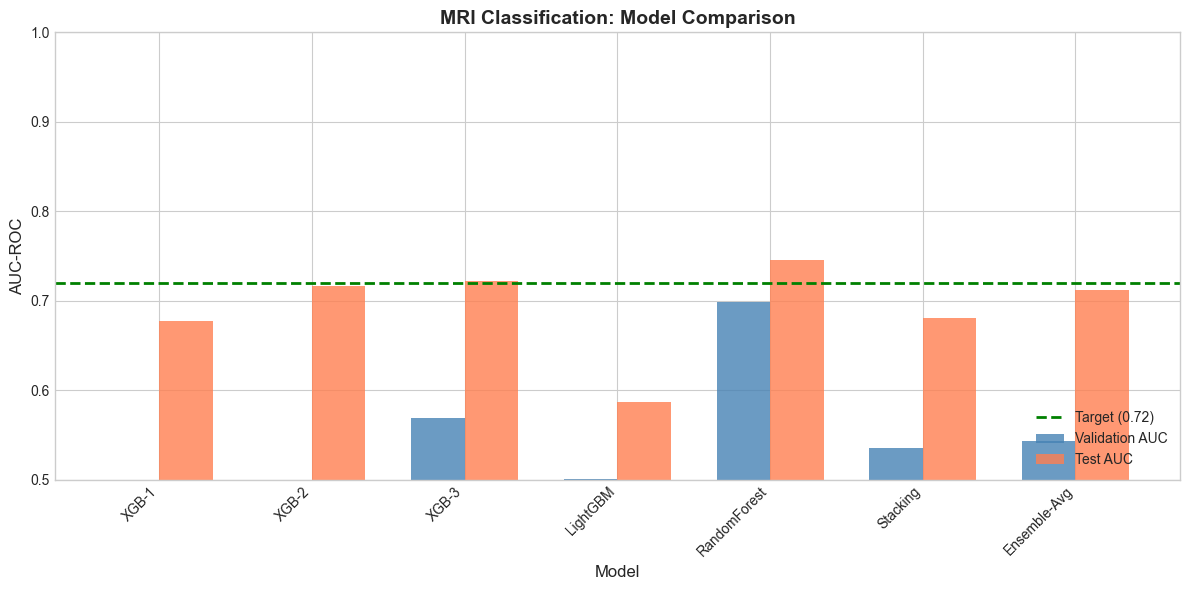

In [8]:
# Bar Chart: Model Comparison
fig, ax = plt.subplots(figsize=(12, 6))

models = list(results.keys())
val_aucs = [results[m]['val'] for m in models]
test_aucs = [results[m]['test'] for m in models]

x = np.arange(len(models))
width = 0.35

bars1 = ax.bar(x - width/2, val_aucs, width, label='Validation AUC', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, test_aucs, width, label='Test AUC', color='coral', alpha=0.8)

ax.axhline(y=0.72, color='green', linestyle='--', linewidth=2, label='Target (0.72)')
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('AUC-ROC', fontsize=12)
ax.set_title('MRI Classification: Model Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45, ha='right')
ax.legend(loc='lower right')
ax.set_ylim(0.5, 1.0)

plt.tight_layout()
plt.savefig('mri_model_comparison.png', dpi=150)
plt.show()

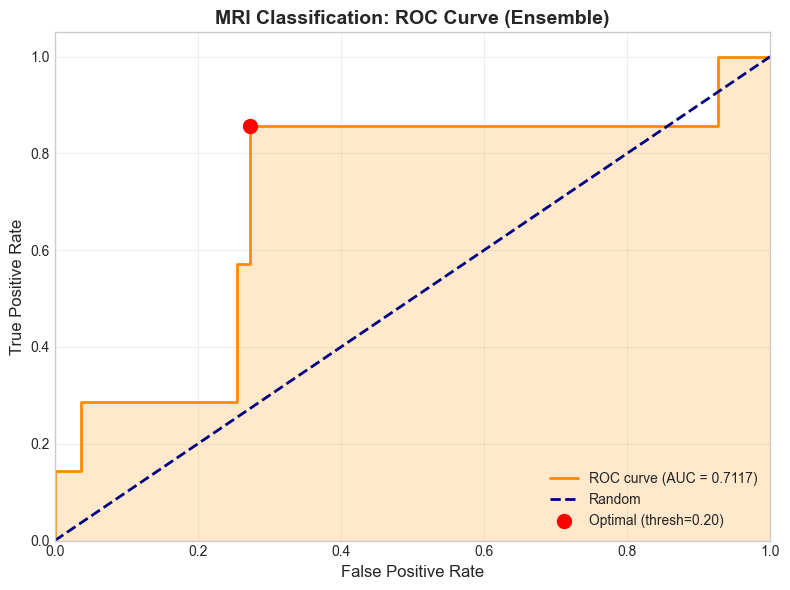

In [9]:
# ROC Curve for Best Model
final_probs = avg_test  # Using Ensemble

fpr, tpr, thresholds = roc_curve(y_test, final_probs)
roc_auc = roc_auc_score(y_test, final_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.fill_between(fpr, tpr, alpha=0.2, color='darkorange')

# Mark optimal threshold
opt_idx = np.argmax(tpr - fpr)
plt.scatter(fpr[opt_idx], tpr[opt_idx], c='red', s=100, zorder=5, label=f'Optimal (thresh={thresholds[opt_idx]:.2f})')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('MRI Classification: ROC Curve (Ensemble)', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('mri_roc_curve.png', dpi=150)
plt.show()

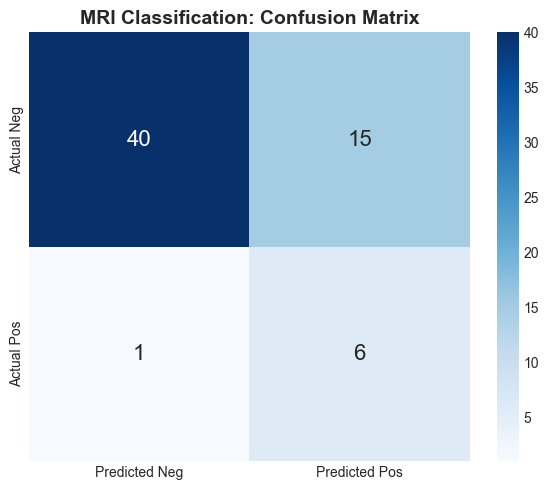

Precision: 0.2857
Recall:    0.8571
F1-Score:  0.4286


In [10]:
# Confusion Matrix
opt_thresh = thresholds[opt_idx]
y_pred = (final_probs >= opt_thresh).astype(int)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Neg', 'Predicted Pos'],
            yticklabels=['Actual Neg', 'Actual Pos'],
            annot_kws={'size': 16})
plt.title('MRI Classification: Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('mri_confusion_matrix.png', dpi=150)
plt.show()

# Metrics
prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='binary', zero_division=0)
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-Score:  {f1:.4f}")

## 9. Summary

In [11]:
# Final Summary
print("="*60)
print("MRI CLASSIFICATION FINAL RESULTS")
print("="*60)
print(f"Best Model: {best[0]}")
print(f"Validation AUC: {best[1]['val']:.4f}")
print(f"Test AUC:       {best[1]['test']:.4f}")
print(f"Test F1:        {f1:.4f}")
print(f"Test Recall:    {rec:.4f}")
print("="*60)

MRI CLASSIFICATION FINAL RESULTS
Best Model: RandomForest
Validation AUC: 0.6987
Test AUC:       0.7455
Test F1:        0.4286
Test Recall:    0.8571
